In [2]:
"""
analizar_experimentos_tesis.py
================================
Analiza los CSV de los experimentos Koopman y MHE+NMPC (planta real) y
genera un reporte HTML detallado con métricas individuales y comparativas.

Uso:
    python analizar_experimentos_tesis.py

Estructura esperada de archivos (en el mismo directorio que el script),
por defecto 5 corridas por método:
    koopman_run1.csv ... koopman_run5.csv
    mhe_nmpc_run1.csv ... mhe_nmpc_run5.csv

Columnas CSV:
    t_s, h1_meas_m, h2_est_m, h3_meas_m, ref_m, u1, u3

El script acepta nombres personalizados y CUALQUIER número de corridas
(no necesariamente igual entre métodos) vía CLI:
    python analizar_experimentos_tesis.py \
        --koopman k1.csv k2.csv k3.csv k4.csv k5.csv \
        --mhe     m1.csv m2.csv m3.csv m4.csv m5.csv
"""

import argparse
import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETROS DEL PROTOCOLO EXPERIMENTAL (deben coincidir con el artículo/tesis)
# ─────────────────────────────────────────────────────────────────────────────
Ts = 2.0           # Período de muestreo [s]
T_SS_START = 400   # Inicio del régimen permanente [s]
REF_CHANGE_2 = 528 # Segunda transición de referencia [s]
TRANSIENT_WINDOW = 60  # Ventana excluida tras cambio de referencia [s]
T_END = 800        # Duración total del experimento [s]

# Número de corridas por método si no se especifica nada por CLI
DEFAULT_N_RUNS = 5

# Referencia escalonada
def reference(t):
    if t < 264:
        return 0.10
    elif t < 528:
        return 0.20
    else:
        return 0.15


# ─────────────────────────────────────────────────────────────────────────────
# CARGA Y VALIDACIÓN DE DATOS
# ─────────────────────────────────────────────────────────────────────────────
REQUIRED_COLS = {"t_s", "h1_meas_m", "h3_meas_m", "ref_m", "u1", "u3"}

# Posibles nombres para la columna h2 estimado (Koopman o MHE+NMPC)
H2_EST_CANDIDATES = ["h2_est_m", "h2_mhe_m", "h2_koop_m", "h2_m"]

def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    # Detectar y normalizar columna de h2 estimado
    h2_col = next((c for c in H2_EST_CANDIDATES if c in df.columns), None)
    if h2_col is None:
        raise ValueError(
            f"Archivo '{path}': no se encontró columna h2. "
            f"Buscados: {H2_EST_CANDIDATES}. "
            f"Columnas presentes: {list(df.columns)}"
        )
    if h2_col != "h2_est_m":
        df = df.rename(columns={h2_col: "h2_est_m"})

    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Archivo '{path}' le faltan columnas: {missing}")

    df = df.sort_values("t_s").reset_index(drop=True)
    # Reconstruir referencia desde tiempo (más confiable que la columna ref_m)
    df["ref_calc"] = df["t_s"].apply(reference)
    return df


# ─────────────────────────────────────────────────────────────────────────────
# MÉTRICAS
# ─────────────────────────────────────────────────────────────────────────────
def steady_state_mask(df: pd.DataFrame) -> pd.Series:
    """
    Máscara booleana para el régimen permanente según el protocolo:
    t > 400 s, excluyendo 60 s tras el segundo cambio de referencia (t=528 s).
    """
    mask = (df["t_s"] > T_SS_START) & ~(
        (df["t_s"] >= REF_CHANGE_2) & (df["t_s"] < REF_CHANGE_2 + TRANSIENT_WINDOW)
    )
    return mask


def rmse(series: pd.Series) -> float:
    return math.sqrt((series ** 2).mean())


def compute_metrics(df: pd.DataFrame, label: str) -> dict:
    error_h2 = df["h2_est_m"] - df["ref_calc"]

    # ── Régimen permanente ──
    ss_mask = steady_state_mask(df)
    df_ss = df[ss_mask]
    err_ss = error_h2[ss_mask]

    rmse_ss = rmse(err_ss) * 100          # en cm
    mae_ss  = err_ss.abs().mean() * 100
    bias_ss = err_ss.mean() * 100
    std_ss  = err_ss.std() * 100
    max_err_ss = err_ss.abs().max() * 100

    # ── Transitorio completo (primeros 400 s) ──
    df_tr = df[df["t_s"] <= T_SS_START]
    err_tr = (df_tr["h2_est_m"] - df_tr["ref_calc"])
    rmse_tr = rmse(err_tr) * 100
    mae_tr  = err_tr.abs().mean() * 100

    # ── Por segmento de referencia ──
    seg_metrics = []
    segments = [(0, 264, 0.10, "Seg 1 (0.10 m)"),
                (264, 528, 0.20, "Seg 2 (0.20 m)"),
                (528, 800, 0.15, "Seg 3 (0.15 m)")]
    for t0, t1, ref_val, name in segments:
        mask_seg = (df["t_s"] >= t0) & (df["t_s"] < t1)
        # Excluir primeros 60s de cada segmento (transitorio)
        mask_seg_ss = mask_seg & (df["t_s"] >= t0 + TRANSIENT_WINDOW)
        e = (df.loc[mask_seg_ss, "h2_est_m"] - ref_val) * 100
        if len(e) > 0:
            seg_metrics.append({
                "name": name,
                "rmse": rmse(e),
                "mae": e.abs().mean(),
                "bias": e.mean(),
                "std": e.std(),
                "n": len(e)
            })
        else:
            seg_metrics.append({"name": name, "rmse": None, "mae": None,
                                 "bias": None, "std": None, "n": 0})

    # ── Señales de control ──
    u1_mean = df["u1"].mean()
    u3_mean = df["u3"].mean()
    u1_std  = df["u1"].std()
    u3_std  = df["u3"].std()

    # ── Energía de control (proxy: suma de u²) ──
    energy_u1 = (df["u1"] ** 2).sum()
    energy_u3 = (df["u3"] ** 2).sum()

    # ── Variación total del control (suavidad) ──
    tv_u1 = df["u1"].diff().abs().sum()
    tv_u3 = df["u3"].diff().abs().sum()

    # ── Overshoot en h2 por segmento ──
    overshoot = []
    for t0, t1, ref_val, name in segments:
        mask_seg = (df["t_s"] >= t0) & (df["t_s"] < t1)
        h2_seg = df.loc[mask_seg, "h2_est_m"]
        if len(h2_seg) > 0:
            os_val = (h2_seg.max() - ref_val) * 100 if ref_val > 0 else None
            overshoot.append({"seg": name, "overshoot_cm": os_val,
                               "h2_max_cm": h2_seg.max() * 100,
                               "h2_min_cm": h2_seg.min() * 100})

    # ── Tiempo de asentamiento aproximado (±5% del ref) para cada segmento ──
    settle_times = []
    for t0, t1, ref_val, name in segments:
        tol = ref_val * 0.05  # 5 %
        mask_seg = (df["t_s"] >= t0) & (df["t_s"] < t1)
        df_seg = df[mask_seg].copy()
        in_band = (df_seg["h2_est_m"] - ref_val).abs() <= tol
        # Último paso fuera de banda
        if in_band.any():
            last_out = df_seg.loc[~in_band, "t_s"]
            if len(last_out) > 0:
                ts_settle = last_out.iloc[-1] - t0
            else:
                ts_settle = 0.0
        else:
            ts_settle = t1 - t0  # no asentó
        settle_times.append({"seg": name, "settle_s": ts_settle})

    # ── Serie temporal (para gráficas JS) ──
    time_series = {
        "t":      df["t_s"].tolist(),
        "h2_est": (df["h2_est_m"] * 100).tolist(),
        "h2_ref": (df["ref_calc"] * 100).tolist(),
        "h1":     (df["h1_meas_m"] * 100).tolist(),
        "h3":     (df["h3_meas_m"] * 100).tolist(),
        "u1":     df["u1"].tolist(),
        "u3":     df["u3"].tolist(),
        "error":  (error_h2 * 100).tolist(),
    }

    return {
        "label": label,
        "n_samples": len(df),
        "duration_s": df["t_s"].max(),
        # Principales
        "rmse_ss_cm": round(rmse_ss, 4),
        "mae_ss_cm":  round(mae_ss, 4),
        "bias_ss_cm": round(bias_ss, 4),
        "std_ss_cm":  round(std_ss, 4),
        "max_err_ss_cm": round(max_err_ss, 4),
        # Transitorio
        "rmse_tr_cm": round(rmse_tr, 4),
        "mae_tr_cm":  round(mae_tr, 4),
        # Control
        "u1_mean": round(u1_mean, 4),
        "u3_mean": round(u3_mean, 4),
        "u1_std":  round(u1_std, 4),
        "u3_std":  round(u3_std, 4),
        "energy_u1": round(energy_u1, 2),
        "energy_u3": round(energy_u3, 2),
        "tv_u1": round(tv_u1, 4),
        "tv_u3": round(tv_u3, 4),
        # Segmentos
        "seg_metrics": seg_metrics,
        "overshoot":   overshoot,
        "settle_times": settle_times,
        # Series temporales
        "ts": time_series,
    }


# ─────────────────────────────────────────────────────────────────────────────
# ESTADÍSTICAS CONSOLIDADAS
# ─────────────────────────────────────────────────────────────────────────────
def group_stats(metrics_list: list, key: str) -> dict:
    vals = [m[key] for m in metrics_list if m[key] is not None]
    if not vals:
        return {}
    return {
        "mean": round(np.mean(vals), 4),
        "std":  round(np.std(vals, ddof=1) if len(vals) > 1 else 0, 4),
        "min":  round(np.min(vals), 4),
        "max":  round(np.max(vals), 4),
    }


# ─────────────────────────────────────────────────────────────────────────────
# GENERACIÓN DEL HTML
# ─────────────────────────────────────────────────────────────────────────────
HTML_TEMPLATE = r"""<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1.0"/>
<title>Análisis Experimental — Koopman vs MHE+NMPC</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>
<link rel="preconnect" href="https://fonts.googleapis.com"/>
<link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:ital,wght@0,300;0,600;1,300&display=swap" rel="stylesheet"/>
<style>
:root{
  --bg:#0d0f14;--surface:#151820;--surface2:#1e2330;--border:#2a3040;
  --koop:#00d4aa;--koop-dim:#00d4aa33;--mhe:#ff6b6b;--mhe-dim:#ff6b6b33;
  --text:#e8eaf0;--text-dim:#8890a8;--accent:#ffd166;
  --font-mono:'IBM Plex Mono',monospace;
  --font-sans:'IBM Plex Sans',sans-serif;
}
*{box-sizing:border-box;margin:0;padding:0}
body{background:var(--bg);color:var(--text);font-family:var(--font-sans);font-weight:300;line-height:1.6}
/* ── Header ── */
header{padding:3rem 2rem 2rem;border-bottom:1px solid var(--border);
  background:linear-gradient(135deg,#0d0f14 60%,#0d1a17)}
header h1{font-family:var(--font-mono);font-size:clamp(1.1rem,3vw,1.6rem);
  font-weight:600;letter-spacing:-0.02em;color:var(--text);line-height:1.3}
header h1 span{color:var(--koop)}
header p{margin-top:.5rem;color:var(--text-dim);font-size:.85rem;
  font-family:var(--font-mono)}
/* ── Layout ── */
.container{max-width:1400px;margin:0 auto;padding:2rem}
/* ── Section ── */
section{margin-bottom:3rem}
.section-title{font-family:var(--font-mono);font-size:.7rem;font-weight:600;
  letter-spacing:.15em;text-transform:uppercase;color:var(--text-dim);
  border-left:3px solid var(--koop);padding-left:.75rem;margin-bottom:1.5rem}
/* ── Cards grid ── */
.cards{display:grid;grid-template-columns:repeat(auto-fit,minmax(220px,1fr));gap:1rem;margin-bottom:2rem}
.card{background:var(--surface);border:1px solid var(--border);border-radius:8px;
  padding:1.25rem 1.5rem;position:relative;overflow:hidden}
.card::before{content:'';position:absolute;top:0;left:0;right:0;height:2px}
.card.koop::before{background:var(--koop)}
.card.mhe::before{background:var(--mhe)}
.card.neutral::before{background:var(--accent)}
.card .label{font-family:var(--font-mono);font-size:.65rem;color:var(--text-dim);
  letter-spacing:.1em;text-transform:uppercase;margin-bottom:.4rem}
.card .value{font-family:var(--font-mono);font-size:1.6rem;font-weight:600;line-height:1}
.card .value.koop{color:var(--koop)}
.card .value.mhe{color:var(--mhe)}
.card .value.accent{color:var(--accent)}
.card .sub{font-size:.75rem;color:var(--text-dim);margin-top:.3rem}
/* ── Comparison banner ── */
.compare-banner{background:var(--surface2);border:1px solid var(--border);
  border-radius:8px;padding:1.5rem 2rem;display:flex;align-items:center;
  gap:2rem;flex-wrap:wrap;margin-bottom:2rem}
.compare-banner .imp{font-family:var(--font-mono);font-size:2rem;font-weight:600;color:var(--koop)}
.compare-banner p{font-size:.9rem;color:var(--text-dim);max-width:400px}
/* ── Table ── */
.tbl-wrap{overflow-x:auto;margin-bottom:2rem}
table{width:100%;border-collapse:collapse;font-size:.82rem}
thead tr{background:var(--surface2)}
th{font-family:var(--font-mono);font-size:.65rem;letter-spacing:.08em;
  text-transform:uppercase;color:var(--text-dim);padding:.75rem 1rem;
  text-align:left;border-bottom:1px solid var(--border)}
td{padding:.65rem 1rem;border-bottom:1px solid var(--border)13;
  font-family:var(--font-mono);font-size:.8rem}
tr:hover td{background:var(--surface2)}
.td-koop{color:var(--koop)}
.td-mhe{color:var(--mhe)}
.td-accent{color:var(--accent)}
.td-good{color:#7ecf7e}
.td-bad{color:#ff8c8c}
/* ── Charts ── */
.chart-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(420px,1fr));gap:1.5rem;margin-bottom:2rem}
.chart-box{background:var(--surface);border:1px solid var(--border);border-radius:8px;padding:1rem}
.chart-box .chart-title{font-family:var(--font-mono);font-size:.7rem;color:var(--text-dim);
  letter-spacing:.1em;text-transform:uppercase;margin-bottom:.75rem}
.chart-box canvas{width:100%!important}
/* ── Run tabs ── */
.tabs{display:flex;gap:.5rem;margin-bottom:1rem;flex-wrap:wrap}
.tab{font-family:var(--font-mono);font-size:.72rem;padding:.4rem .9rem;
  border-radius:4px;cursor:pointer;border:1px solid var(--border);
  background:transparent;color:var(--text-dim);transition:all .2s}
.tab:hover{border-color:var(--text-dim);color:var(--text)}
.tab.active.koop{background:var(--koop-dim);border-color:var(--koop);color:var(--koop)}
.tab.active.mhe{background:var(--mhe-dim);border-color:var(--mhe);color:var(--mhe)}
.run-panel{display:none}.run-panel.active{display:block}
/* ── Badge ── */
.badge{display:inline-block;font-family:var(--font-mono);font-size:.62rem;
  padding:.15rem .5rem;border-radius:3px;letter-spacing:.05em}
.badge.best{background:#00d4aa22;color:var(--koop);border:1px solid #00d4aa44}
.badge.worst{background:#ff6b6b22;color:var(--mhe);border:1px solid #ff6b6b44}
/* ── Progress bar ── */
.bar-wrap{display:flex;align-items:center;gap:.75rem}
.bar-track{flex:1;height:6px;background:var(--border);border-radius:3px;overflow:hidden}
.bar-fill{height:100%;border-radius:3px;transition:width .4s}
/* ── Footer ── */
footer{border-top:1px solid var(--border);padding:1.5rem 2rem;
  font-family:var(--font-mono);font-size:.72rem;color:var(--text-dim);
  display:flex;justify-content:space-between;flex-wrap:wrap;gap:.5rem}
</style>
</head>
<body>
<header>
  <div style="max-width:1400px;margin:0 auto">
    <h1>Koopman Observer+MPC vs <span>MHE+NMPC</span> — Análisis Experimental Completo</h1>
    <p>Sistema de tres tanques acoplados · Planta real · Universidad Distrital FJC · __N_TOTAL__ experimentos · Ts = 2s</p>
  </div>
</header>

<div class="container">

<!-- ═══════════════════════════════════════════════════════════ RESUMEN GLOBAL -->
<section>
<div class="section-title">Resumen comparativo global</div>

<div class="compare-banner">
  <div>
    <div style="font-family:var(--font-mono);font-size:.65rem;color:var(--text-dim);letter-spacing:.1em;text-transform:uppercase">Diferencia RMSE₍ₛₛ₎ media</div>
    <div class="imp" id="pct-improvement">—</div>
  </div>
  <div>
    <p>Comparación entre el esquema Koopman (Observador de Luenberger sobre EDMD de 8 observables + KoopmanMPC) y el esquema de referencia MHE+NMPC, ambos validados en lazo cerrado sobre la planta física de tres tanques, con __N_KOOP__ corridas Koopman y __N_MHE__ corridas MHE+NMPC.</p>
  </div>
  <div style="margin-left:auto;display:flex;flex-direction:column;gap:.5rem">
    <div style="font-family:var(--font-mono);font-size:.7rem;color:var(--text-dim)">RMSE<sub>SS</sub> media Koopman</div>
    <div style="font-family:var(--font-mono);font-size:1.4rem;color:var(--koop)" id="koop-mean-badge">—</div>
    <div style="font-family:var(--font-mono);font-size:.7rem;color:var(--text-dim);margin-top:.5rem">RMSE<sub>SS</sub> media MHE+NMPC</div>
    <div style="font-family:var(--font-mono);font-size:1.4rem;color:var(--mhe)" id="mhe-mean-badge">—</div>
  </div>
</div>

<div class="cards" id="summary-cards"></div>
</section>

<!-- ═══════════════════════════════════════════════════════════ TABLA CONSOLIDADA -->
<section>
<div class="section-title">Tabla consolidada — todas las corridas</div>
<div class="tbl-wrap">
<table id="main-table">
<thead>
<tr>
  <th>Método</th><th>Corrida</th>
  <th>RMSE<sub>SS</sub> h₂ [cm]</th>
  <th>MAE<sub>SS</sub> [cm]</th>
  <th>Bias<sub>SS</sub> [cm]</th>
  <th>σ error [cm]</th>
  <th>Err. máx. [cm]</th>
  <th>RMSE transient. [cm]</th>
  <th>ū₁</th><th>ū₃</th>
  <th>TV u₁</th><th>TV u₃</th>
  <th>Muestras</th>
</tr>
</thead>
<tbody id="main-tbody"></tbody>
</table>
</div>
</section>

<!-- ═══════════════════════════════════════════════════════════ MÉTRICAS POR SEGMENTO -->
<section>
<div class="section-title">RMSE por segmento de referencia (régimen permanente por tramo)</div>
<div class="tbl-wrap">
<table id="seg-table">
<thead>
<tr>
  <th>Método</th><th>Corrida</th>
  <th>Seg 1 · 0.10 m [cm]</th>
  <th>Seg 2 · 0.20 m [cm]</th>
  <th>Seg 3 · 0.15 m [cm]</th>
  <th>Bias Seg 1</th><th>Bias Seg 2</th><th>Bias Seg 3</th>
</tr>
</thead>
<tbody id="seg-tbody"></tbody>
</table>
</div>
</section>

<!-- ═══════════════════════════════════════════════════════════ TIEMPOS DE ASENTAMIENTO -->
<section>
<div class="section-title">Tiempo de asentamiento ±5% · Overshoot por segmento</div>
<div class="tbl-wrap">
<table id="settle-table">
<thead>
<tr>
  <th>Método</th><th>Corrida</th>
  <th>Ts Seg1 [s]</th><th>Ts Seg2 [s]</th><th>Ts Seg3 [s]</th>
  <th>OS Seg1 [cm]</th><th>OS Seg2 [cm]</th><th>OS Seg3 [cm]</th>
  <th>h₂ max [cm]</th><th>h₂ min [cm]</th>
</tr>
</thead>
<tbody id="settle-tbody"></tbody>
</table>
</div>
</section>

<!-- ═══════════════════════════════════════════════════════════ GRÁFICAS COMPARATIVAS -->
<section>
<div class="section-title">Distribución de métricas clave</div>
<div class="chart-grid">
  <div class="chart-box">
    <div class="chart-title">RMSE SS h₂ — todas las corridas [cm]</div>
    <canvas id="chart-rmse-bar"></canvas>
  </div>
  <div class="chart-box">
    <div class="chart-title">Bias SS h₂ — todas las corridas [cm]</div>
    <canvas id="chart-bias-bar"></canvas>
  </div>
  <div class="chart-box">
    <div class="chart-title">MAE SS vs σ error [cm]</div>
    <canvas id="chart-mae-sigma"></canvas>
  </div>
  <div class="chart-box">
    <div class="chart-title">Energía de control u₁ + u₃</div>
    <canvas id="chart-energy"></canvas>
  </div>
</div>
</section>

<!-- ═══════════════════════════════════════════════════════════ CORRIDAS INDIVIDUALES -->
<section>
<div class="section-title">Análisis individual por corrida</div>

<!-- KOOPMAN -->
<div style="margin-bottom:1.5rem">
  <div style="font-family:var(--font-mono);font-size:.8rem;color:var(--koop);
    margin-bottom:.75rem;letter-spacing:.05em">▶ KOOPMAN OBSERVER + KOOPMANMPC</div>
  <div class="tabs" id="koop-tabs"></div>
  <div id="koop-panels"></div>
</div>

<!-- MHE+NMPC -->
<div>
  <div style="font-family:var(--font-mono);font-size:.8rem;color:var(--mhe);
    margin-bottom:.75rem;letter-spacing:.05em">▶ MHE + NMPC</div>
  <div class="tabs" id="mhe-tabs"></div>
  <div id="mhe-panels"></div>
</div>
</section>

</div><!-- /container -->

<footer>
  <span>Generado automáticamente · analizar_experimentos_tesis.py</span>
  <span id="footer-date"></span>
</footer>

<!-- ═══════════════════════════════════════════════════════════ DATOS JSON -->
<script id="exp-data" type="application/json">__EXP_DATA__</script>

<!-- ═══════════════════════════════════════════════════════════ LÓGICA JS -->
<script>
const DATA = JSON.parse(document.getElementById('exp-data').textContent);
const koopData = DATA.filter(d => d.method === 'koopman');
const mheData  = DATA.filter(d => d.method === 'mhe');

document.getElementById('footer-date').textContent =
  'Generado: ' + new Date().toLocaleString('es-CO');

// ── Helpers ──
const fmt = (v, d=3) => v == null ? '—' : v.toFixed(d);
const pct = (a, b) => (((b - a) / b) * 100).toFixed(1) + '%';

function colorVal(val, goodIfLow=true) {
  if (val == null) return '—';
  const good = goodIfLow ? 'td-good' : 'td-bad';
  const bad  = goodIfLow ? 'td-bad'  : 'td-good';
  return val;
}

// ── Summary cards ──
function statOf(arr, key) {
  const vals = arr.map(d => d[key]).filter(v => v != null);
  return {
    mean: vals.reduce((a,b) => a+b, 0) / vals.length,
    min:  Math.min(...vals),
    max:  Math.max(...vals),
    std:  Math.sqrt(vals.map(v => (v - vals.reduce((a,b)=>a+b,0)/vals.length)**2)
           .reduce((a,b)=>a+b,0) / Math.max(vals.length-1,1))
  };
}

const kStat = statOf(koopData, 'rmse_ss_cm');
const mStat = statOf(mheData,  'rmse_ss_cm');
// Diferencia con signo: positiva => Koopman tiene mayor RMSE (peor);
// negativa => Koopman tiene menor RMSE (mejor) que MHE+NMPC
const diffPct = ((kStat.mean - mStat.mean) / mStat.mean * 100).toFixed(1);

document.getElementById('pct-improvement').textContent =
  (diffPct < 0 ? `${Math.abs(diffPct)}% mejor (Koopman)` : `${diffPct}% peor (Koopman)`);
document.getElementById('koop-mean-badge').textContent = kStat.mean.toFixed(3) + ' cm';
document.getElementById('mhe-mean-badge').textContent  = mStat.mean.toFixed(3) + ' cm';

const summaryCards = [
  {label:`RMSE SS Koopman (media, n=${koopData.length})`, value: kStat.mean.toFixed(3)+' cm', cls:'koop', sub:`σ = ${kStat.std.toFixed(3)} · rango [${kStat.min.toFixed(3)}, ${kStat.max.toFixed(3)}] cm`},
  {label:`RMSE SS MHE+NMPC (media, n=${mheData.length})`, value: mStat.mean.toFixed(3)+' cm', cls:'mhe',  sub:`σ = ${mStat.std.toFixed(3)} · rango [${mStat.min.toFixed(3)}, ${mStat.max.toFixed(3)}] cm`},
  {label:'Diferencia relativa',     value: (diffPct<0?'-':'+')+Math.abs(diffPct)+'%', cls:'neutral', sub:'Koopman vs MHE+NMPC en régimen permanente (negativo = Koopman mejor)'},
  {label:'Muestras por experimento',value: koopData[0]?.n_samples ?? mheData[0]?.n_samples ?? '—', cls:'neutral', sub:'Ts = 2 s · duración 800 s'},
];

const sc = document.getElementById('summary-cards');
summaryCards.forEach(c => {
  sc.innerHTML += `<div class="card ${c.cls}">
    <div class="label">${c.label}</div>
    <div class="value ${c.cls}">${c.value}</div>
    <div class="sub">${c.sub}</div>
  </div>`;
});

// Tarjetas de MAE
const kMAE = statOf(koopData,'mae_ss_cm');
const mMAE = statOf(mheData, 'mae_ss_cm');
const extraCards = [
  {label:'MAE SS Koopman (media)', value: kMAE.mean.toFixed(3)+' cm', cls:'koop', sub:'error absoluto medio régimen permanente'},
  {label:'MAE SS MHE+NMPC (media)', value: mMAE.mean.toFixed(3)+' cm', cls:'mhe',  sub:'error absoluto medio régimen permanente'},
];
extraCards.forEach(c => {
  sc.innerHTML += `<div class="card ${c.cls}">
    <div class="label">${c.label}</div>
    <div class="value ${c.cls}">${c.value}</div>
    <div class="sub">${c.sub}</div>
  </div>`;
});

// ── Tabla principal ──
const tbody = document.getElementById('main-tbody');
const allData = [...koopData, ...mheData];
const bestKoop = koopData.length ? Math.min(...koopData.map(d=>d.rmse_ss_cm)) : null;
const bestMHE  = mheData.length  ? Math.min(...mheData.map(d=>d.rmse_ss_cm))  : null;

allData.forEach(d => {
  const isKoop = d.method === 'koopman';
  const cls = isKoop ? 'td-koop' : 'td-mhe';
  const isBest = (isKoop && d.rmse_ss_cm === bestKoop) || (!isKoop && d.rmse_ss_cm === bestMHE);
  tbody.innerHTML += `<tr>
    <td class="${cls}">${isKoop ? 'Koopman' : 'MHE+NMPC'}</td>
    <td class="${cls}">${d.label} ${isBest ? '<span class="badge best">best</span>' : ''}</td>
    <td class="${cls}">${fmt(d.rmse_ss_cm)}</td>
    <td>${fmt(d.mae_ss_cm)}</td>
    <td style="color:${Math.abs(d.bias_ss_cm) > 0.3 ? '#ff8c8c' : '#7ecf7e'}">${fmt(d.bias_ss_cm)}</td>
    <td>${fmt(d.std_ss_cm)}</td>
    <td>${fmt(d.max_err_ss_cm)}</td>
    <td>${fmt(d.rmse_tr_cm)}</td>
    <td>${fmt(d.u1_mean, 3)}</td>
    <td>${fmt(d.u3_mean, 3)}</td>
    <td>${fmt(d.tv_u1, 2)}</td>
    <td>${fmt(d.tv_u3, 2)}</td>
    <td>${d.n_samples}</td>
  </tr>`;
});

// Fila de medias
['koopman','mhe'].forEach(m => {
  const grp = DATA.filter(d => d.method === m);
  if (grp.length === 0) return;
  const keys = ['rmse_ss_cm','mae_ss_cm','bias_ss_cm','std_ss_cm','max_err_ss_cm','rmse_tr_cm'];
  const avgs = keys.map(k => {
    const vals = grp.map(d=>d[k]).filter(v=>v!=null);
    return vals.reduce((a,b)=>a+b,0)/vals.length;
  });
  const cls = m === 'koopman' ? 'td-koop' : 'td-mhe';
  tbody.innerHTML += `<tr style="font-weight:600;background:var(--surface2)">
    <td class="${cls}">${m==='koopman'?'Koopman':'MHE+NMPC'} MEDIA (n=${grp.length})</td>
    <td>—</td>
    ${avgs.map(v=>`<td class="${cls}">${fmt(v)}</td>`).join('')}
    <td>—</td><td>—</td><td>—</td><td>—</td><td>—</td>
  </tr>`;
});

// ── Tabla por segmento ──
const segTbody = document.getElementById('seg-tbody');
allData.forEach(d => {
  const isKoop = d.method === 'koopman';
  const cls = isKoop ? 'td-koop' : 'td-mhe';
  const segs = d.seg_metrics;
  const rmses = segs.map(s => s.rmse != null ? fmt(s.rmse) : '—');
  const biases = segs.map(s => s.bias != null ? fmt(s.bias) : '—');
  segTbody.innerHTML += `<tr>
    <td class="${cls}">${isKoop?'Koopman':'MHE+NMPC'}</td>
    <td class="${cls}">${d.label}</td>
    ${rmses.map(v=>`<td>${v}</td>`).join('')}
    ${biases.map(v=>`<td>${v}</td>`).join('')}
  </tr>`;
});

// ── Tabla asentamiento ──
const settTbody = document.getElementById('settle-tbody');
allData.forEach(d => {
  const isKoop = d.method === 'koopman';
  const cls = isKoop ? 'td-koop' : 'td-mhe';
  const st = d.settle_times;
  const os = d.overshoot;
  settTbody.innerHTML += `<tr>
    <td class="${cls}">${isKoop?'Koopman':'MHE+NMPC'}</td>
    <td class="${cls}">${d.label}</td>
    ${st.map(s=>`<td>${fmt(s.settle_s,1)}</td>`).join('')}
    ${os.map(s=>`<td>${s.overshoot_cm!=null?fmt(s.overshoot_cm,2):'—'}</td>`).join('')}
    <td>${os.length>0?fmt(os.reduce((a,b)=>a.h2_max_cm>b.h2_max_cm?a:b).h2_max_cm,2):'—'}</td>
    <td>${os.length>0?fmt(os.reduce((a,b)=>a.h2_min_cm<b.h2_min_cm?a:b).h2_min_cm,2):'—'}</td>
  </tr>`;
});

// ── Chart helpers ──
const chartDefaults = {
  responsive:true,
  plugins:{legend:{labels:{color:'#8890a8',font:{family:'IBM Plex Mono',size:11}}}},
  scales:{
    x:{ticks:{color:'#8890a8',font:{family:'IBM Plex Mono',size:10}},grid:{color:'#2a3040'}},
    y:{ticks:{color:'#8890a8',font:{family:'IBM Plex Mono',size:10}},grid:{color:'#2a3040'}}
  }
};

// Bar: RMSE SS
new Chart(document.getElementById('chart-rmse-bar'), {
  type:'bar',
  data:{
    labels:[...koopData.map(d=>`K-${d.label}`),...mheData.map(d=>`MHE-${d.label}`)],
    datasets:[{
      label:'RMSE SS [cm]',
      data:[...koopData.map(d=>d.rmse_ss_cm),...mheData.map(d=>d.rmse_ss_cm)],
      backgroundColor:[...koopData.map(()=>'#00d4aa66'),...mheData.map(()=>'#ff6b6b66')],
      borderColor:[...koopData.map(()=>'#00d4aa'),...mheData.map(()=>'#ff6b6b')],
      borderWidth:1
    }]
  },
  options:{...chartDefaults}
});

// Bar: Bias
new Chart(document.getElementById('chart-bias-bar'), {
  type:'bar',
  data:{
    labels:[...koopData.map(d=>`K-${d.label}`),...mheData.map(d=>`MHE-${d.label}`)],
    datasets:[{
      label:'Bias SS [cm]',
      data:[...koopData.map(d=>d.bias_ss_cm),...mheData.map(d=>d.bias_ss_cm)],
      backgroundColor:[...koopData.map(d=>d.bias_ss_cm>=0?'#00d4aa66':'#ffd16666'),
                       ...mheData.map(d=>d.bias_ss_cm>=0?'#ff6b6b66':'#ffd16666')],
      borderColor:[...koopData.map(()=>'#00d4aa'),...mheData.map(()=>'#ff6b6b')],
      borderWidth:1
    }]
  },
  options:{...chartDefaults}
});

// Scatter: MAE vs sigma
new Chart(document.getElementById('chart-mae-sigma'), {
  type:'scatter',
  data:{
    datasets:[
      {label:'Koopman',
       data:koopData.map(d=>({x:d.mae_ss_cm,y:d.std_ss_cm,label:d.label})),
       backgroundColor:'#00d4aa',pointRadius:8,pointHoverRadius:10},
      {label:'MHE+NMPC',
       data:mheData.map(d=>({x:d.mae_ss_cm,y:d.std_ss_cm,label:d.label})),
       backgroundColor:'#ff6b6b',pointRadius:8,pointHoverRadius:10},
    ]
  },
  options:{...chartDefaults,
    plugins:{...chartDefaults.plugins,
      tooltip:{callbacks:{label:ctx=>`${ctx.dataset.label} ${ctx.raw.label}: MAE=${fmt(ctx.raw.x)} σ=${fmt(ctx.raw.y)}`}}},
    scales:{
      x:{...chartDefaults.scales.x,title:{display:true,text:'MAE SS [cm]',color:'#8890a8'}},
      y:{...chartDefaults.scales.y,title:{display:true,text:'σ error [cm]',color:'#8890a8'}}
    }
  }
});

// Bar: Energía
new Chart(document.getElementById('chart-energy'), {
  type:'bar',
  data:{
    labels:[...koopData.map(d=>`K-${d.label}`),...mheData.map(d=>`MHE-${d.label}`)],
    datasets:[
      {label:'Energía u₁',
       data:[...koopData.map(d=>d.energy_u1),...mheData.map(d=>d.energy_u1)],
       backgroundColor:'#00d4aa44',borderColor:'#00d4aa',borderWidth:1},
      {label:'Energía u₃',
       data:[...koopData.map(d=>d.energy_u3),...mheData.map(d=>d.energy_u3)],
       backgroundColor:'#ffd16644',borderColor:'#ffd166',borderWidth:1},
    ]
  },
  options:{...chartDefaults}
});

// ── Paneles individuales ──
function buildRunPanels(dataArr, containerId, tabsId, method) {
  const tabs = document.getElementById(tabsId);
  const cont = document.getElementById(containerId);
  dataArr.forEach((d, i) => {
    const isActive = i === 0;
    const cls = method;
    tabs.innerHTML += `<button class="tab ${isActive?'active':''} ${cls}"
      onclick="switchTab('${containerId}','${tabsId}',${i},'${cls}')">${d.label}</button>`;

    const panelId = `${containerId}-panel-${i}`;
    const chartId1 = `chart-${method}-${i}-traj`;
    const chartId2 = `chart-${method}-${i}-ctrl`;
    const chartId3 = `chart-${method}-${i}-err`;

    let segRows = d.seg_metrics.map(s =>
      `<tr><td>${s.name}</td><td>${s.rmse!=null?fmt(s.rmse):'—'}</td>
      <td>${s.mae!=null?fmt(s.mae):'—'}</td>
      <td style="color:${Math.abs(s.bias??0)>0.3?'#ff8c8c':'#7ecf7e'}">${s.bias!=null?fmt(s.bias):'—'}</td>
      <td>${s.n}</td></tr>`).join('');

    cont.innerHTML += `<div class="run-panel ${isActive?'active':''}" id="${panelId}">
      <div class="cards" style="margin-bottom:1.5rem">
        <div class="card ${cls}"><div class="label">RMSE SS h₂</div>
          <div class="value ${cls}">${fmt(d.rmse_ss_cm)} cm</div></div>
        <div class="card neutral"><div class="label">Bias SS</div>
          <div class="value accent">${fmt(d.bias_ss_cm)} cm</div></div>
        <div class="card neutral"><div class="label">MAE SS</div>
          <div class="value accent">${fmt(d.mae_ss_cm)} cm</div></div>
        <div class="card neutral"><div class="label">RMSE Transitorio</div>
          <div class="value accent">${fmt(d.rmse_tr_cm)} cm</div></div>
        <div class="card neutral"><div class="label">σ error SS</div>
          <div class="value accent">${fmt(d.std_ss_cm)} cm</div></div>
        <div class="card neutral"><div class="label">Err. máx. SS</div>
          <div class="value accent">${fmt(d.max_err_ss_cm)} cm</div></div>
      </div>
      <div class="chart-grid">
        <div class="chart-box">
          <div class="chart-title">Trayectoria h₂ estimada vs referencia [cm]</div>
          <canvas id="${chartId1}"></canvas>
        </div>
        <div class="chart-box">
          <div class="chart-title">Error de seguimiento h₂ [cm]</div>
          <canvas id="${chartId3}"></canvas>
        </div>
        <div class="chart-box">
          <div class="chart-title">Señales de control u₁, u₃</div>
          <canvas id="${chartId2}"></canvas>
        </div>
        <div class="chart-box" style="align-self:start">
          <div class="chart-title">RMSE por segmento [cm]</div>
          <table style="width:100%;font-size:.78rem">
          <thead><tr><th>Seg.</th><th>RMSE</th><th>MAE</th><th>Bias</th><th>N</th></tr></thead>
          <tbody>${segRows}</tbody></table>
        </div>
      </div>
    </div>`;
  });

  // Draw charts after DOM insertion
  dataArr.forEach((d, i) => {
    const ts = d.ts;
    const step = Math.max(1, Math.floor(ts.t.length / 300));
    const idx = ts.t.map((_,j)=>j).filter(j=>j%step===0);
    const t = idx.map(j=>ts.t[j]);

    const lineOpts = {...chartDefaults,
      elements:{point:{radius:0}},
      plugins:{...chartDefaults.plugins,legend:{...chartDefaults.plugins.legend}},
    };

    const accentColor = method==='koopman' ? '#00d4aa' : '#ff6b6b';
    const accentBg    = method==='koopman' ? '#00d4aa11' : '#ff6b6b11';

    // Trajectory
    new Chart(document.getElementById(`chart-${method}-${i}-traj`), {
      type:'line',
      data:{
        labels: t,
        datasets:[
          {label:'h₂ est [cm]', data:idx.map(j=>ts.h2_est[j]),
           borderColor: accentColor,
           borderWidth:1.5,tension:0.1},
          {label:'Referencia', data:idx.map(j=>ts.h2_ref[j]),
           borderColor:'#ffd166',borderWidth:1,borderDash:[4,3],tension:0},
          {label:'h₁ med [cm]', data:idx.map(j=>ts.h1[j]),
           borderColor:'#6b8cff',borderWidth:1,tension:0.1},
          {label:'h₃ med [cm]', data:idx.map(j=>ts.h3[j]),
           borderColor:'#c46bff',borderWidth:1,tension:0.1},
        ]
      },
      options:{...lineOpts,
        scales:{x:{...lineOpts.scales.x,title:{display:true,text:'t [s]',color:'#8890a8'}},
                y:{...lineOpts.scales.y,title:{display:true,text:'nivel [cm]',color:'#8890a8'}}}}
    });

    // Error
    new Chart(document.getElementById(`chart-${method}-${i}-err`), {
      type:'line',
      data:{
        labels: t,
        datasets:[{
          label:'error h₂ [cm]', data:idx.map(j=>ts.error[j]),
          borderColor: accentColor,
          borderWidth:1.5,fill:true,
          backgroundColor: accentBg,
          tension:0.1
        }]
      },
      options:{...lineOpts,
        scales:{x:{...lineOpts.scales.x,title:{display:true,text:'t [s]',color:'#8890a8'}},
                y:{...lineOpts.scales.y,title:{display:true,text:'error [cm]',color:'#8890a8'}}}}
    });

    // Control
    new Chart(document.getElementById(`chart-${method}-${i}-ctrl`), {
      type:'line',
      data:{
        labels: t,
        datasets:[
          {label:'u₁', data:idx.map(j=>ts.u1[j]),
           borderColor: accentColor,borderWidth:1.5,tension:0.1},
          {label:'u₃', data:idx.map(j=>ts.u3[j]),
           borderColor:'#ffd166',borderWidth:1.5,tension:0.1},
        ]
      },
      options:{...lineOpts,
        scales:{x:{...lineOpts.scales.x,title:{display:true,text:'t [s]',color:'#8890a8'}},
                y:{...lineOpts.scales.y,min:0,max:1,
                   title:{display:true,text:'u [0,1]',color:'#8890a8'}}}}
    });
  });
}

buildRunPanels(koopData, 'koop-panels', 'koop-tabs', 'koop');
buildRunPanels(mheData,  'mhe-panels',  'mhe-tabs',  'mhe');

function switchTab(containerId, tabsId, idx, cls) {
  document.querySelectorAll(`#${containerId} .run-panel`).forEach((p,i) => {
    p.classList.toggle('active', i === idx);
  });
  document.querySelectorAll(`#${tabsId} .tab`).forEach((t,i) => {
    t.classList.toggle('active', i === idx);
    if(i===idx) t.classList.add(cls); else t.classList.remove(cls);
  });
}
</script>
</body>
</html>
"""


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def default_file_list(prefix: str, n: int) -> list:
    """Genera la lista de nombres por defecto: prefix_run1.csv ... prefix_runN.csv"""
    return [f"{prefix}_run{i}.csv" for i in range(1, n + 1)]


def main():
    parser = argparse.ArgumentParser(
        description="Análisis experimental Koopman vs MHE+NMPC (planta real)"
    )
    # nargs='+' permite CUALQUIER número de archivos (no fijo a 3 ni a 5).
    # Si el usuario no pasa nada, se generan N=DEFAULT_N_RUNS nombres por defecto.
    parser.add_argument(
        "--koopman", nargs="+", metavar="CSV", default=None,
        help=f"Lista de CSV de Koopman, en orden de corrida "
             f"(por defecto: {DEFAULT_N_RUNS} archivos koopman_run1..{DEFAULT_N_RUNS}.csv)"
    )
    parser.add_argument(
        "--mhe", nargs="+", metavar="CSV", default=None,
        help=f"Lista de CSV de MHE+NMPC, en orden de corrida "
             f"(por defecto: {DEFAULT_N_RUNS} archivos mhe_nmpc_run1..{DEFAULT_N_RUNS}.csv)"
    )
    parser.add_argument(
        "--n-runs", type=int, default=DEFAULT_N_RUNS,
        help=f"Número de corridas por método a usar para generar los nombres "
             f"por defecto si --koopman/--mhe no se especifican (default: {DEFAULT_N_RUNS})"
    )
    parser.add_argument("--output", default="reporte_experimentos_tesis.html",
                        help="Nombre del HTML de salida")
    # Ignorar argumentos desconocidos (Jupyter pasa --f=kernel-xxx.json, etc.)
    args, _ = parser.parse_known_args()

    koopman_files = args.koopman if args.koopman is not None \
        else default_file_list("koopman", args.n_runs)
    mhe_files = args.mhe if args.mhe is not None \
        else default_file_list("mhe_nmpc", args.n_runs)

    all_metrics = []

    print("\n╔══════════════════════════════════════════════════════════╗")
    print("║  Análisis Experimental — Koopman vs MHE+NMPC (planta real) ║")
    print("╚══════════════════════════════════════════════════════════╝\n")
    print(f"  Corridas Koopman esperadas : {len(koopman_files)}")
    print(f"  Corridas MHE+NMPC esperadas: {len(mhe_files)}\n")

    for method, files in [("koopman", koopman_files), ("mhe", mhe_files)]:
        label_method = "KOOPMAN" if method == "koopman" else "MHE+NMPC"
        print(f"▶ {label_method}")
        for i, fpath in enumerate(files, 1):
            label = f"Run {i}"
            if not os.path.exists(fpath):
                print(f"  ✗ Archivo no encontrado: {fpath}  (se omite)")
                continue
            try:
                df = load_csv(fpath)
                m  = compute_metrics(df, label)
                m["method"] = method
                all_metrics.append(m)
                print(f"  ✓ {label} ({fpath}): "
                      f"RMSE_SS={m['rmse_ss_cm']:.4f} cm  "
                      f"MAE_SS={m['mae_ss_cm']:.4f} cm  "
                      f"Bias={m['bias_ss_cm']:.4f} cm  "
                      f"N={m['n_samples']}")
            except Exception as e:
                print(f"  ✗ Error en {fpath}: {e}")

    if not all_metrics:
        print("\n✗ No se pudieron cargar datos. Verifica los nombres de archivos.")
        sys.exit(1)

    n_koop_loaded = sum(1 for m in all_metrics if m["method"] == "koopman")
    n_mhe_loaded  = sum(1 for m in all_metrics if m["method"] == "mhe")

    if n_koop_loaded == 0:
        print("\n⚠ Advertencia: no se cargó ninguna corrida de Koopman.")
    if n_mhe_loaded == 0:
        print("\n⚠ Advertencia: no se cargó ninguna corrida de MHE+NMPC.")

    # Resumen consolidado
    print("\n──────────────────────────────────────────────────────────────")
    print("RESUMEN ESTADÍSTICO")
    print("──────────────────────────────────────────────────────────────")
    for method in ("koopman", "mhe"):
        grp = [m for m in all_metrics if m["method"] == method]
        if not grp:
            continue
        label_method = "KOOPMAN" if method == "koopman" else "MHE+NMPC"
        stats = group_stats(grp, "rmse_ss_cm")
        print(f"\n{label_method} (n={len(grp)}):")
        print(f"  RMSE_SS  : media={stats['mean']:.4f}  σ={stats['std']:.4f}  "
              f"min={stats['min']:.4f}  max={stats['max']:.4f} [cm]")
        s2 = group_stats(grp, "mae_ss_cm")
        print(f"  MAE_SS   : media={s2['mean']:.4f}  σ={s2['std']:.4f} [cm]")
        s3 = group_stats(grp, "bias_ss_cm")
        print(f"  Bias_SS  : media={s3['mean']:.4f}  σ={s3['std']:.4f} [cm]")

    koop_grp = [m for m in all_metrics if m["method"] == "koopman"]
    mhe_grp  = [m for m in all_metrics if m["method"] == "mhe"]
    if koop_grp and mhe_grp:
        k_mean = np.mean([m["rmse_ss_cm"] for m in koop_grp])
        m_mean = np.mean([m["rmse_ss_cm"] for m in mhe_grp])
        diff = (k_mean - m_mean) / m_mean * 100
        if diff < 0:
            print(f"\n  → Koopman es {abs(diff):.1f}% mejor que MHE+NMPC en RMSE_SS medio")
        else:
            print(f"\n  → Koopman es {diff:.1f}% peor que MHE+NMPC en RMSE_SS medio")

    # Generar HTML
    json_data = json.dumps(all_metrics)
    html = HTML_TEMPLATE.replace("__EXP_DATA__", json_data)
    html = html.replace("__N_TOTAL__", str(len(all_metrics)))
    html = html.replace("__N_KOOP__", str(n_koop_loaded))
    html = html.replace("__N_MHE__", str(n_mhe_loaded))

    out_path = args.output
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(html)

    print(f"\n✓ Reporte generado: {out_path}")
    print("  Abre este archivo en cualquier navegador moderno.\n")


if __name__ == "__main__":
    main()


╔══════════════════════════════════════════════════════════╗
║  Análisis Experimental — Koopman vs MHE+NMPC (planta real) ║
╚══════════════════════════════════════════════════════════╝

  Corridas Koopman esperadas : 5
  Corridas MHE+NMPC esperadas: 5

▶ KOOPMAN
  ✓ Run 1 (koopman_run1.csv): RMSE_SS=0.2037 cm  MAE_SS=0.1741 cm  Bias=-0.0086 cm  N=400
  ✓ Run 2 (koopman_run2.csv): RMSE_SS=0.2022 cm  MAE_SS=0.1678 cm  Bias=-0.0016 cm  N=400
  ✓ Run 3 (koopman_run3.csv): RMSE_SS=0.2241 cm  MAE_SS=0.1890 cm  Bias=-0.0034 cm  N=400
  ✓ Run 4 (koopman_run4.csv): RMSE_SS=0.1874 cm  MAE_SS=0.1557 cm  Bias=-0.0129 cm  N=400
  ✓ Run 5 (koopman_run5.csv): RMSE_SS=0.1831 cm  MAE_SS=0.1521 cm  Bias=-0.0121 cm  N=400
▶ MHE+NMPC
  ✓ Run 1 (mhe_nmpc_run1.csv): RMSE_SS=0.4052 cm  MAE_SS=0.3615 cm  Bias=-0.3615 cm  N=400
  ✓ Run 2 (mhe_nmpc_run2.csv): RMSE_SS=0.3212 cm  MAE_SS=0.2853 cm  Bias=-0.2852 cm  N=400
  ✓ Run 3 (mhe_nmpc_run3.csv): RMSE_SS=0.3396 cm  MAE_SS=0.3114 cm  Bias=-0.3113 cm  N=400
  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ── Carga de datos (mejores corridas de cada método) ───────────────────────
# Koopman Run 5 — RMSE_SS = 0.1831 cm  (mejor de 5 corridas)
# MHE+NMPC Run 5 — RMSE_SS = 0.3140 cm (mejor de 5 corridas)
df_koop = pd.read_csv("outputs_real/koopman_v4b_fix_20260617_015445.csv")
df_mhe  = pd.read_csv("outputs_real/mhe_nmpc_real_20260617_095117.csv")

for df in [df_koop, df_mhe]:
    df.columns = df.columns.str.strip()

# Convertir a cm  (ref_m ya viene en el CSV)
t_k   = df_koop["t_s"].values
t_m   = df_mhe["t_s"].values
h2_k  = df_koop["h2_est_m"].values * 100
h2_m  = df_mhe["h2_est_m"].values  * 100
ref_k = df_koop["ref_m"].values    * 100
ref_m = df_mhe["ref_m"].values     * 100
err_k = h2_k - ref_k
err_m = h2_m - ref_m
u1_k  = df_koop["u1"].values
u1_m  = df_mhe["u1"].values

# ── Métricas SS (protocolo idéntico a Tabla 8: t>400s, excluye 60s post-cambio) ──
def rmse_ss(t, err, ref_changes=(264, 528), settle=60, t_start=400):
    mask = t > t_start
    for tc in ref_changes:
        mask &= ~((t >= tc) & (t < tc + settle))
    return float(np.sqrt(np.mean(err[mask]**2)))

def bias_ss(t, err, ref_changes=(264, 528), settle=60, t_start=400):
    mask = t > t_start
    for tc in ref_changes:
        mask &= ~((t >= tc) & (t < tc + settle))
    return float(np.mean(err[mask]))

rmse_k = rmse_ss(t_k, err_k)
rmse_m = rmse_ss(t_m, err_m)
mejora  = (rmse_m - rmse_k) / rmse_m * 100
bias_k  = bias_ss(t_k, err_k)   # Koopman bias (h2_est - ref), SS filtrado
bias_m  = bias_ss(t_m, err_m)   # MHE+NMPC bias (h2_est - ref), SS filtrado

# ── Estilo ─────────────────────────────────────────────────────────────────
FONTSIZE  = 11
COLOR_K   = "#1f77b4"
COLOR_M   = "#d62728"
COLOR_REF = "#2ca02c"

plt.rcParams.update({
    "font.size"        : FONTSIZE,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Figura: 3 paneles verticales ───────────────────────────────────────────
fig = plt.figure(figsize=(11, 9))
gs  = gridspec.GridSpec(3, 1,
                         height_ratios=[2.6, 1.6, 1.0],
                         hspace=0.07,
                         left=0.09, right=0.97,
                         top=0.93,  bottom=0.07)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

CHANGE_TIMES = [264, 528]

# ── Panel 1: Trayectoria h2 ────────────────────────────────────────────────
ax1.step(t_k, ref_k, where="post",
         color=COLOR_REF, lw=1.4, ls="--", zorder=2,
         label=r"Reference $h_2^{\mathrm{ref}}$")
ax1.plot(t_k, h2_k,
         color=COLOR_K, lw=1.6, zorder=3,
         label=fr"Koopman (Run 5)  —  RMSE$_{{SS}}$ = {rmse_k:.3f} cm")
ax1.plot(t_m, h2_m,
         color=COLOR_M, lw=1.6, ls="--", zorder=3,
         label=fr"MHE+NMPC (Run 5) —  RMSE$_{{SS}}$ = {rmse_m:.3f} cm")

ax1.axvspan(400, 800, alpha=0.07, color="gold", zorder=1, label="SS region ($t>400$ s)")
for tc in CHANGE_TIMES:
    ax1.axvline(tc, color="gray", lw=0.9, ls=":", alpha=0.7)

seg_labels = [(132, "Seg. 1\n$h_2^{ref}=10$ cm"),
              (396, "Seg. 2\n$h_2^{ref}=20$ cm"),
              (664, "Seg. 3\n$h_2^{ref}=15$ cm")]
for x, lbl in seg_labels:
    ax1.text(x, 23.5, lbl, ha="center", va="top",
             fontsize=FONTSIZE - 2, color="dimgray")

# Recuadro de métricas — bias_k = Koopman, bias_m = MHE+NMPC (orden correcto)
stats = (
    f"Steady-state metrics\n"
    f"  Koopman  bias: {bias_k:+.3f} cm\n"
    f"  MHE+NMPC bias: {bias_m:+.3f} cm\n"
    f"  RMSE reduction: {mejora:.1f}%"
)
ax1.text(402, 2.0, stats,
         fontsize=FONTSIZE - 2, family="monospace",
         va="bottom", ha="left",
         bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="gray", alpha=0.92))

ax1.set_ylabel(r"$\hat{h}_2$ [cm]", fontsize=FONTSIZE)
ax1.set_ylim(0, 25)
ax1.set_yticks([0, 5, 10, 15, 20, 25])
ax1.grid(alpha=0.22, lw=0.5)
ax1.legend(fontsize=FONTSIZE - 1, loc="upper right", framealpha=0.92, edgecolor="gray")
plt.setp(ax1.get_xticklabels(), visible=False)

# ── Panel 2: Error de seguimiento ─────────────────────────────────────────
ax2.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax2.axhspan(-1, 1, alpha=0.09, color="gray", zorder=1)
ax2.axhline( 1, color="gray", lw=0.6, ls=":", alpha=0.55)
ax2.axhline(-1, color="gray", lw=0.6, ls=":", alpha=0.55)
ax2.plot(t_k, err_k, color=COLOR_K, lw=1.4, label="Koopman")
ax2.plot(t_m, err_m, color=COLOR_M, lw=1.4, ls="--", label="MHE+NMPC")
ax2.axvspan(400, 800, alpha=0.07, color="gold", zorder=1)
for tc in CHANGE_TIMES:
    ax2.axvline(tc, color="gray", lw=0.9, ls=":", alpha=0.7)
ax2.text(600, 8.5, "SS window\n($t > 400$ s)",
         ha="center", fontsize=FONTSIZE - 3, color="goldenrod", style="italic")
ax2.set_ylabel(r"$\hat{h}_2 - h_2^{\mathrm{ref}}$ [cm]", fontsize=FONTSIZE)
ax2.set_ylim(-12, 12)
ax2.set_yticks([-10, -5, 0, 5, 10])
ax2.legend(fontsize=FONTSIZE - 1, loc="lower right", framealpha=0.92, edgecolor="gray")
ax2.grid(alpha=0.22, lw=0.5)
plt.setp(ax2.get_xticklabels(), visible=False)

# ── Panel 3: Señal de control u1 ──────────────────────────────────────────
ax3.plot(t_k, u1_k, color=COLOR_K, lw=1.1, alpha=0.85, label=r"$u_1$ Koopman")
ax3.plot(t_m, u1_m, color=COLOR_M, lw=1.1, alpha=0.85, ls="--", label=r"$u_1$ MHE+NMPC")
for tc in CHANGE_TIMES:
    ax3.axvline(tc, color="gray", lw=0.9, ls=":", alpha=0.7)
ax3.set_ylabel(r"$u_1$", fontsize=FONTSIZE)
ax3.set_xlabel("Time [s]", fontsize=FONTSIZE)
ax3.set_xlim(0, 800)
ax3.set_ylim(-0.05, 1.08)
ax3.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
ax3.set_xticks([0, 100, 200, 264, 400, 528, 600, 800])
ax3.legend(fontsize=FONTSIZE - 1, loc="upper right", framealpha=0.92, edgecolor="gray")
ax3.grid(alpha=0.22, lw=0.5)

fig.suptitle(
    "Experimental comparison: Koopman Observer (Run 5, best) vs. MHE+NMPC (Run 5, best)\n"
    "Three-tank hydraulic system — closed-loop, partial state measurement",
    fontsize=FONTSIZE, y=0.97
)

os.makedirs("img", exist_ok=True)
plt.savefig("img/overlay_experimental.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"✓ Guardada en img/overlay_experimental.png")
print(f"  Koopman  RMSE_SS = {rmse_k:.3f} cm  |  bias = {bias_k:+.4f} cm")
print(f"  MHE+NMPC RMSE_SS = {rmse_m:.3f} cm  |  bias = {bias_m:+.4f} cm")
print(f"  Mejora   = {mejora:.1f}%")

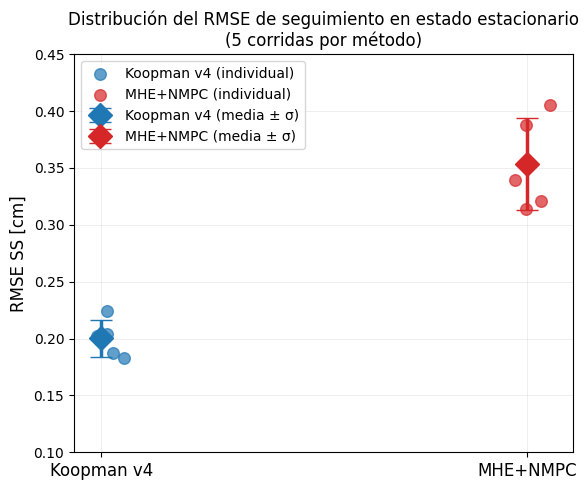

Koopman  — media=0.2001 cm  σ=0.0162 cm
MHE+NMPC — media=0.3535 cm  σ=0.0407 cm
Mejora Koopman vs MHE+NMPC: 43.4%


In [1]:
import matplotlib.pyplot as plt
import numpy as np

metodos = ['Koopman v4', 'MHE+NMPC']
# Valores en orden de numeración de corridas (Run 1..5) — consistente con main.tex
rmse_koopman = [0.2037, 0.2022, 0.2241, 0.1874, 0.1831]  # Run 1..5
rmse_mhe     = [0.4052, 0.3212, 0.3396, 0.3877, 0.3140]  # Run 1..5 (Run5=mejor=0.3140)

medias = [np.mean(rmse_koopman), np.mean(rmse_mhe)]
sigmas = [np.std(rmse_koopman, ddof=1), np.std(rmse_mhe, ddof=1)]

fig, ax = plt.subplots(figsize=(6, 5))

for i, (metodo, rmse, color) in enumerate(zip(
    metodos,
    [rmse_koopman, rmse_mhe],
    ['#1f77b4', '#d62728']
)):
    x = np.full(len(rmse), i, dtype=float)
    ax.scatter(x + np.random.uniform(-0.08, 0.08, len(rmse)),
               rmse, color=color, s=70, alpha=0.7, zorder=3,
               label=f'{metodo} (individual)')

for i, (media, sigma, color) in enumerate(zip(medias, sigmas, ['#1f77b4', '#d62728'])):
    ax.errorbar(i, media, yerr=sigma, fmt='D', color=color,
                markersize=12, capsize=8, lw=2.5, zorder=4,
                label=f'{metodos[i]} (media ± σ)')

ax.set_ylabel('RMSE SS [cm]', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(metodos, fontsize=12)
ax.set_ylim(0.10, 0.45)
ax.grid(alpha=0.3, lw=0.5)
ax.legend(fontsize=10)
ax.set_title('Distribución del RMSE de seguimiento en estado estacionario\n'
             '(5 corridas por método)', fontsize=12)

plt.tight_layout()
plt.savefig('img/rmse_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Koopman  — media={medias[0]:.4f} cm  σ={sigmas[0]:.4f} cm")
print(f"MHE+NMPC — media={medias[1]:.4f} cm  σ={sigmas[1]:.4f} cm")
print(f"Mejora Koopman vs MHE+NMPC: {(medias[1]-medias[0])/medias[1]*100:.1f}%")